# 12 · Consolidación del grupo **DIETARY**

**Proyecto:** Modelo de longevidad NHANES 2017-2018 (ciclo `_J`)
**Capa:** `01_raw` (.xpt) → **`02_intermediate`** → `03_primary`

## Objetivo
Resumir los **2 recordatorios dietéticos de 24h** (día 1 y día 2) en un dataset intermedio
con la **ingesta usual** de nutrientes clave y features de **calidad de la dieta**.

**Datasets de este grupo (2):**
- `dr1tot_j` — totales de nutrientes del **día 1** (168 columnas).
- `dr2tot_j` — totales de nutrientes del **día 2** (85 columnas).

## Decisiones clave
- **Promediamos día 1 y día 2** para estimar la ingesta usual (reduce la enorme variabilidad
  día a día de un solo recordatorio). Si falta el día 2, se usa solo el día 1.
- **Filtramos recordatorios no confiables** (`DR1DRSTZ`/`DR2DRSTZ` ≠ 1) → a `NaN`.
- Preferimos **densidades y % de energía** sobre gramos absolutos: ajustan por el tamaño total
  de la ingesta y son mejores indicadores de calidad dietética.
- Descartamos las decenas de columnas de ácidos grasos individuales, suplementos (`DRD350/370`),
  pesos muestrales (`WTDR*`) y metadatos del recordatorio.


## 1. Setup

In [1]:
%load_ext kedro.ipython

[06/16/26 19:45:48] INFO     Using 'conf\logging.yml' as logging configuration. You can change this ]8;id=14502;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\framework\project\__init__.py\__init__.py]8;;\:]8;id=14503;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\framework\project\__init__.py#281\281]8;;\
                             by setting the KEDRO_LOGGING_CONFIG environment variable accordingly.                 

[06/16/26 19:45:49] INFO     Registered line magic '%reload_kedro'                                   ]8;id=14510;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=14511;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\ipython\__init__.py#67\67]8;;\

                    INFO     Registered line magic '%load_node'                                      ]8;id=14517;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=14518;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\ipython\__init__.py#69\69]8;;\

                    INFO     Resolved project path as:                                              ]8;id=14524;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=14525;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\ipython\__init__.py#193\193]8;;\
                             C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes.                                        
                             To set a different path, run '%reload_kedro <project_root>'                           

[06/16/26 19:45:54] INFO     No typed parameter requirements found, returning original   ]8;id=14532;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\validation\parameter_validator.py\parameter_validator.py]8;;\:]8;id=14533;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\validation\parameter_validator.py#124\124]8;;\
                             parameters                                                                            

[06/16/26 19:46:00] INFO     Kedro is sending anonymous usage data with the sole purpose of improving ]8;id=14540;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro_telemetry\plugin.py\plugin.py]8;;\:]8;id=14541;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro_telemetry\plugin.py#273\273]8;;\
                             the product. No personal data or IP addresses are stored on our side. To              
                             opt out, set the `KEDRO_DISABLE_TELEMETRY` or `DO_NOT_TRACK` environment              
                             variables, or create a `.telemetry` file in the current working                       
                             directory with the contents `consent: false`. To hide this message,                   
                             explicitly grant or deny consent. Read more at                                        
                             https://docs.kedro.org/en/stable/about/telemetry/                                     

                    INFO     Kedro project Nhanes                                                   ]8;id=14547;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=14548;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\ipython\__init__.py#159\159]8;;\

                    INFO     Defined global variable 'context', 'session', 'catalog' and            ]8;id=14554;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\ipython\__init__.py\__init__.py]8;;\:]8;id=14555;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\ipython\__init__.py#160\160]8;;\
                             'pipelines'                                                                           

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 120)
plt.rcParams["figure.dpi"] = 110

PROJ = Path(context.project_path)
OUT_DIR = PROJ / "data" / "02_intermediate"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("Salida:", OUT_DIR)

Salida: C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\data\02_intermediate


## 2. Carga de los recordatorios día 1 y día 2

In [3]:
dr1 = catalog.load("dr1tot_j_dataset")
dr2 = catalog.load("dr2tot_j_dataset")
print("DR1 (día 1):", dr1.shape)
print("DR2 (día 2):", dr2.shape)

[06/16/26 19:46:02] INFO     Loading data from dr1tot_j_dataset (GenericDataset)...            ]8;id=14562;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=14563;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\io\data_catalog.py#1053\1053]8;;\

[06/16/26 19:46:03] INFO     Loading data from dr2tot_j_dataset (GenericDataset)...            ]8;id=14568;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=14569;file://C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\.venv\Lib\site-packages\kedro\io\data_catalog.py#1053\1053]8;;\

DR1 (día 1): (8704, 168)
DR2 (día 2): (8704, 85)


## 3. Selección de nutrientes core y filtro de confiabilidad

Los nutrientes vienen con prefijo de día: `DR1T...` (día 1) y `DR2T...` (día 2). Definimos un
mapa `nombre_legible -> sufijo` y reconstruimos el código de cada día.

`DR1DRSTZ`/`DR2DRSTZ` es el **estado del recordatorio**: `1` = confiable y cumple criterios
mínimos. Cualquier otro valor → ese día se marca como `NaN` (no es ingesta válida).

In [4]:
# nombre_legible -> sufijo del nutriente (sin el prefijo DR1T/DR2T)
NUTRIENTS = {
    "energia_kcal":  "KCAL",
    "proteina_g":    "PROT",
    "carbo_g":       "CARB",
    "azucar_g":      "SUGR",
    "fibra_g":       "FIBE",
    "grasa_total_g": "TFAT",
    "grasa_sat_g":   "SFAT",
    "grasa_mono_g":  "MFAT",
    "grasa_poli_g":  "PFAT",
    "colesterol_mg": "CHOL",
    "sodio_mg":      "SODI",
    "potasio_mg":    "POTA",
    "calcio_mg":     "CALC",
    "magnesio_mg":   "MAGN",
    "hierro_mg":     "IRON",
    "zinc_mg":       "ZINC",
    "selenio_mcg":   "SELE",
    "vit_c_mg":      "VC",
    "vit_d_mcg":     "VD",
    "vit_e_mg":      "ATOC",
    "vit_k_mcg":     "VK",
    "vit_b12_mcg":   "VB12",
    "folato_dfe":    "FDFE",
    "cafeina_mg":    "CAFF",
    "alcohol_g":     "ALCO",
}

def day_table(df, day):
    # Extrae SEQN + nutrientes de un día, anulando recordatorios no confiables
    pref = f"DR{day}T"
    status = f"DR{day}DRSTZ"
    cols = {f"{pref}{suf}": name for name, suf in NUTRIENTS.items()
            if f"{pref}{suf}" in df.columns}
    out = df[["SEQN"] + list(cols)].rename(columns=cols).copy()
    out["SEQN"] = out["SEQN"].astype("int64")
    # recordatorio no confiable (status != 1) -> nutrientes a NaN.
    # Usamos DataFrame.where con una máscara 2D (broadcast de la condición por fila):
    # mantiene el valor donde el recordatorio es confiable y pone NaN donde no.
    if status in df.columns:
        nut = list(cols.values())
        reliable = df[status].eq(1).to_numpy()
        mask2d = np.broadcast_to(reliable[:, None], (len(out), len(nut)))
        out[nut] = out[nut].where(mask2d)
        print(f"Día {day}: recordatorios no confiables anulados = {(~reliable).sum()}")
    return out.drop_duplicates("SEQN").set_index("SEQN")

d1 = day_table(dr1, 1)
d2 = day_table(dr2, 2)
print("d1:", d1.shape, "| d2:", d2.shape)

Día 1: recordatorios no confiables anulados = 1220
Día 2: recordatorios no confiables anulados = 2202
d1: (8704, 25) | d2: (8704, 25)


## 4. Ingesta usual = promedio de los dos días

Para cada nutriente promediamos día 1 y día 2 (`nanmean`): si el día 2 falta, queda el día 1.
Así obtenemos una estimación más estable de la ingesta habitual.

In [5]:
# Alineamos por SEQN (union) y promediamos por nutriente
diet = d1.join(d2, how="outer", lsuffix="_d1", rsuffix="_d2")

avg = pd.DataFrame(index=diet.index)
for name in NUTRIENTS:
    c1, c2 = f"{name}_d1", f"{name}_d2"
    cols = [c for c in (c1, c2) if c in diet.columns]
    avg[name] = diet[cols].mean(axis=1)  # nanmean: ignora el día faltante

print("Tabla de ingesta usual:", avg.shape)
# cuantos tienen 2 dias vs 1 dia (para el reporte)
n_d2 = d2.index.isin(d1.index).sum()
print(f"Participantes con día 1: {len(d1)} | también con día 2: {len(d2)}")
avg.head()

Tabla de ingesta usual: (8704, 25)
Participantes con día 1: 8704 | también con día 2: 8704


,energia_kcal,proteina_g,carbo_g,azucar_g,fibra_g,grasa_total_g,grasa_sat_g,grasa_mono_g,grasa_poli_g,colesterol_mg,sodio_mg,potasio_mg,calcio_mg,magnesio_mg,hierro_mg,zinc_mg,selenio_mcg,vit_c_mg,vit_d_mcg,vit_e_mg,vit_k_mcg,vit_b12_mcg,folato_dfe,cafeina_mg,alcohol_g
SEQN,,,,,,,,,,,,,,,,,,,,,,,,,
93703,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
93704,1293.0,41.035,195.075,105.670,7.05,40.130,10.870,12.3880,12.8775,107.0,1771.5,1691.5,730.5,149.0,6.805,6.155,49.90,49.20,6.75,4.775,48.20,4.285,350.0,7.000000e+00,5.397605e-79
93705,1218.5,29.265,152.470,67.295,10.75,56.085,15.257,18.1570,18.4290,208.0,3010.5,1399.0,503.5,159.0,9.660,3.705,45.00,12.35,1.85,5.905,93.35,0.790,248.5,2.535000e+02,5.397605e-79
93706,1987.0,94.190,89.820,14.730,7.10,137.390,35.169,45.8050,49.8730,462.0,3657.0,1247.0,869.0,187.0,8.520,8.050,118.50,9.70,0.70,10.020,138.40,2.300,354.0,5.397605e-79,5.397605e-79
93707,1784.5,75.755,170.635,85.015,9.40,91.580,32.175,34.5585,15.1255,620.5,2515.5,1787.0,381.0,197.5,11.055,11.265,107.05,10.50,2.75,9.810,45.00,3.510,135.5,1.550000e+01,5.397605e-79


## 5. Limpieza: ingestas implausibles

Energías extremas suelen ser errores de reporte. Aplicamos cortes clásicos de plausibilidad
para kcal (Willett): fuera de ~[500, 5000] kcal/día → `NaN` en energía (y por ende afecta a las
densidades que dependen de ella).

In [6]:
before = avg["energia_kcal"].notna().sum()
avg.loc[(avg["energia_kcal"] < 500) | (avg["energia_kcal"] > 5000), "energia_kcal"] = np.nan
print("Energías implausibles -> NaN:", before - avg["energia_kcal"].notna().sum())

Energías implausibles -> NaN: 114


## 6. Ingeniería de características — calidad de la dieta

| Feature | Fórmula | Señal |
|---|---|---|
| `prot_pct_kcal` | proteína·4 / kcal × 100 | % de energía de proteína (sarcopenia/saciedad) |
| `carb_pct_kcal` | carbohidrato·4 / kcal × 100 | % de energía de carbohidrato |
| `grasa_pct_kcal` | grasa·9 / kcal × 100 | % de energía de grasa |
| `sat_pct_kcal` | grasa sat·9 / kcal × 100 | grasa saturada (riesgo CV) |
| `azucar_pct_kcal` | azúcar·4 / kcal × 100 | azúcares añadidos/totales |
| `fibra_dens` | fibra / kcal × 1000 | densidad de fibra (g/1000 kcal) |
| `ps_ratio` | grasa poli / grasa sat | razón P:S (calidad de grasas) |
| `na_k_ratio` | sodio / potasio | razón Na:K (riesgo cardiovascular) |

Factores de Atwater: proteína y carbohidrato = 4 kcal/g, grasa = 9 kcal/g.

In [7]:
k = avg["energia_kcal"].replace(0, np.nan)
avg["prot_pct_kcal"]   = avg["proteina_g"]   * 4 / k * 100
avg["carb_pct_kcal"]   = avg["carbo_g"]      * 4 / k * 100
avg["grasa_pct_kcal"]  = avg["grasa_total_g"] * 9 / k * 100
avg["sat_pct_kcal"]    = avg["grasa_sat_g"]  * 9 / k * 100
avg["azucar_pct_kcal"] = avg["azucar_g"]     * 4 / k * 100
avg["fibra_dens"]      = avg["fibra_g"] / k * 1000
avg["ps_ratio"]        = avg["grasa_poli_g"] / avg["grasa_sat_g"].replace(0, np.nan)
avg["na_k_ratio"]      = avg["sodio_mg"] / avg["potasio_mg"].replace(0, np.nan)

# Descartamos los gramos de grasa desglosados (ya resumidos en %/ratios)
DROP = ["grasa_total_g", "grasa_sat_g", "grasa_mono_g", "grasa_poli_g",
        "carbo_g", "azucar_g"]
diet_final = avg.drop(columns=[c for c in DROP if c in avg.columns])
print("Dataset dietético final:", diet_final.shape)
print("Columnas:", list(diet_final.columns))

Dataset dietético final: (8704, 27)
Columnas: ['energia_kcal', 'proteina_g', 'fibra_g', 'colesterol_mg', 'sodio_mg', 'potasio_mg', 'calcio_mg', 'magnesio_mg', 'hierro_mg', 'zinc_mg', 'selenio_mcg', 'vit_c_mg', 'vit_d_mcg', 'vit_e_mg', 'vit_k_mcg', 'vit_b12_mcg', 'folato_dfe', 'cafeina_mg', 'alcohol_g', 'prot_pct_kcal', 'carb_pct_kcal', 'grasa_pct_kcal', 'sat_pct_kcal', 'azucar_pct_kcal', 'fibra_dens', 'ps_ratio', 'na_k_ratio']


## 7. Visualizaciones de control

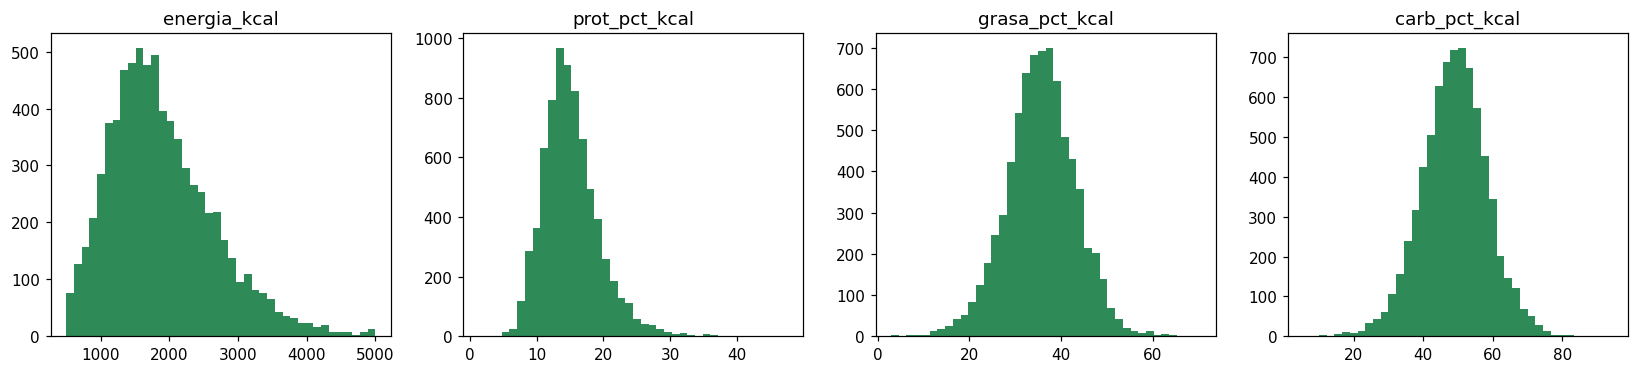

In [8]:
# Grafico 1: distribucion de energia y aporte calorico por macronutriente
fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
for ax, c in zip(axes, ["energia_kcal", "prot_pct_kcal", "grasa_pct_kcal", "carb_pct_kcal"]):
    ax.hist(diet_final[c].dropna(), bins=40, color="seagreen")
    ax.set_title(c)
plt.tight_layout(); plt.show()

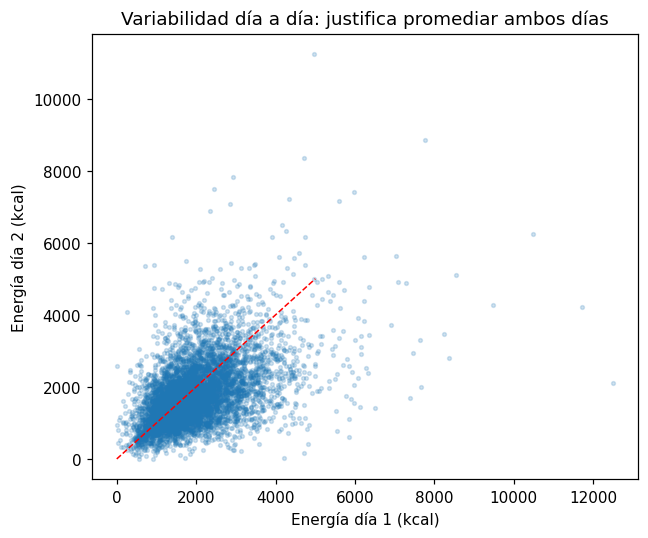

Correlación energía día1-día2: 0.48


In [9]:
# Grafico 2: ingesta dia 1 vs dia 2 de energia (variabilidad intra-individuo)
if "energia_kcal_d1" in diet.columns and "energia_kcal_d2" in diet.columns:
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(diet["energia_kcal_d1"], diet["energia_kcal_d2"], s=6, alpha=0.2)
    ax.plot([0, 5000], [0, 5000], "r--", lw=1)
    ax.set_xlabel("Energía día 1 (kcal)"); ax.set_ylabel("Energía día 2 (kcal)")
    ax.set_title("Variabilidad día a día: justifica promediar ambos días")
    plt.tight_layout(); plt.show()
    r = diet[["energia_kcal_d1", "energia_kcal_d2"]].corr().iloc[0, 1]
    print("Correlación energía día1-día2:", round(r, 2))

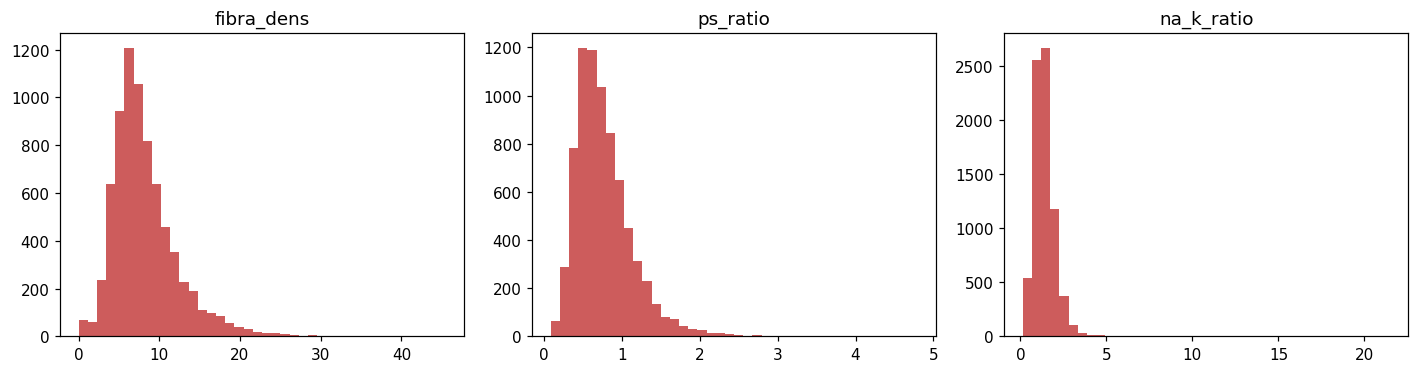

In [10]:
# Grafico 3: razones de calidad dietetica
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, c in zip(axes, ["fibra_dens", "ps_ratio", "na_k_ratio"]):
    ax.hist(diet_final[c].dropna(), bins=40, color="indianred")
    ax.set_title(c)
plt.tight_layout(); plt.show()

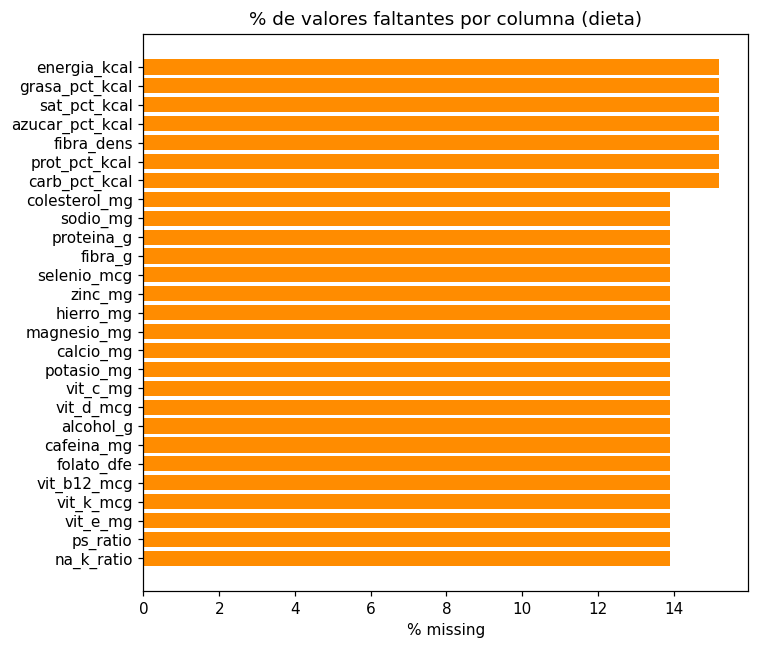

,%_missing
energia_kcal,15.2
grasa_pct_kcal,15.2
sat_pct_kcal,15.2
azucar_pct_kcal,15.2
fibra_dens,15.2
prot_pct_kcal,15.2
carb_pct_kcal,15.2
colesterol_mg,13.9
sodio_mg,13.9
proteina_g,13.9


In [11]:
# Grafico 4: % missing por columna
miss = (diet_final.isna().mean() * 100).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(miss.index[::-1], miss.values[::-1], color="darkorange")
ax.set_title("% de valores faltantes por columna (dieta)")
ax.set_xlabel("% missing"); plt.tight_layout(); plt.show()
miss.round(1).to_frame("%_missing")

## 8. Exportación a `02_intermediate`

In [12]:
out_path = OUT_DIR / "diet_intermediate.parquet"
diet_final.to_parquet(out_path)
print("Guardado:", out_path, "| shape:", diet_final.shape)
diet_final.head()

Guardado: C:\Users\Felipe\Desktop\NHANES_PROJECT\nhanes\data\02_intermediate\diet_intermediate.parquet | shape: (8704, 27)


,energia_kcal,proteina_g,fibra_g,colesterol_mg,sodio_mg,potasio_mg,calcio_mg,magnesio_mg,hierro_mg,zinc_mg,selenio_mcg,vit_c_mg,vit_d_mcg,vit_e_mg,vit_k_mcg,vit_b12_mcg,folato_dfe,cafeina_mg,alcohol_g,prot_pct_kcal,carb_pct_kcal,grasa_pct_kcal,sat_pct_kcal,azucar_pct_kcal,fibra_dens,ps_ratio,na_k_ratio
SEQN,,,,,,,,,,,,,,,,,,,,,,,,,,,
93703,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
93704,1293.0,41.035,7.05,107.0,1771.5,1691.5,730.5,149.0,6.805,6.155,49.90,49.20,6.75,4.775,48.20,4.285,350.0,7.000000e+00,5.397605e-79,12.694509,60.348028,27.932715,7.566125,32.689869,5.452436,1.184683,1.047295
93705,1218.5,29.265,10.75,208.0,3010.5,1399.0,503.5,159.0,9.660,3.705,45.00,12.35,1.85,5.905,93.35,0.790,248.5,2.535000e+02,5.397605e-79,9.606894,50.051703,41.425113,11.269019,22.091096,8.822323,1.207905,2.151894
93706,1987.0,94.190,7.10,462.0,3657.0,1247.0,869.0,187.0,8.520,8.050,118.50,9.70,0.70,10.020,138.40,2.300,354.0,5.397605e-79,5.397605e-79,18.961248,18.081530,62.229995,15.929592,2.965274,3.573226,1.418095,2.932638
93707,1784.5,75.755,9.40,620.5,2515.5,1787.0,381.0,197.5,11.055,11.265,107.05,10.50,2.75,9.810,45.00,3.510,135.5,1.550000e+01,5.397605e-79,16.980667,38.248249,46.187728,16.227235,19.056318,5.267582,0.470101,1.407666


## 9. Conclusiones del grupo Dietary

- De **2 recordatorios** (168 + 85 columnas) llegamos a una tabla compacta de ingesta usual y
  calidad dietética.
- **Promediar día 1 y día 2** reduce la variabilidad intra-individuo (la correlación día1-día2
  suele ser baja → un solo día es poco fiable).
- Priorizamos **% de energía, densidades y razones** (P:S, Na:K) sobre gramos absolutos.
- Filtramos recordatorios no confiables e ingestas energéticas implausibles.
- ⚠️ Cobertura: la dieta es Tier 2; tendrá más missing que otros grupos. Se decide su uso
  definitivo tras evaluar el missingness sobre la población objetivo en `03_primary`.

### Referencias
- Willett, W. (2013). *Nutritional Epidemiology* (3rd ed.). Oxford University Press.
- CDC/NCHS. *NHANES 2017-2018 Dietary Interview — Total Nutrient Intakes (DR1TOT/DR2TOT).*
